In [1]:
#IMPORT LIBRARIES
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-nu

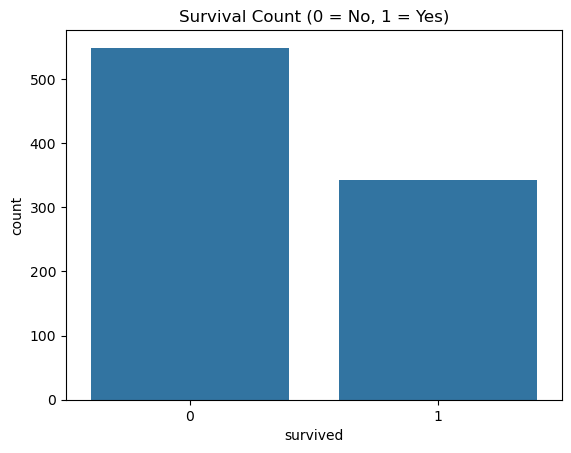

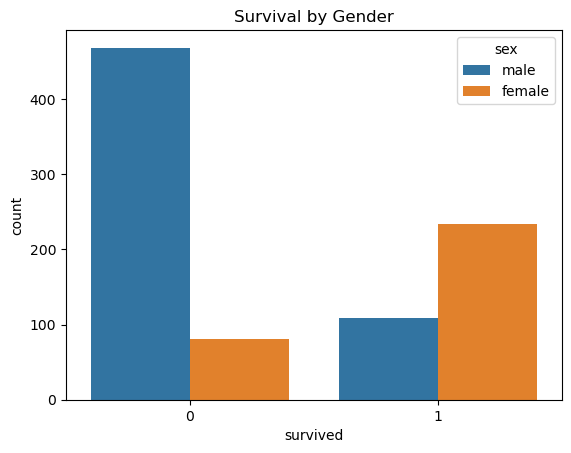

C:\Users\sahap\AppData\Local\Temp\ipykernel_13812\4103162733.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_df['age'].fillna(titanic_df['age'].median(),inplace = True)
C:\Users\sahap\AppData\Local\Temp\ipykernel_13812\4103162733.py:31: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behave

              precision    recall  f1-score   support

           0       0.83      0.86      0.85       105
           1       0.79      0.76      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.81      0.82      0.82       179



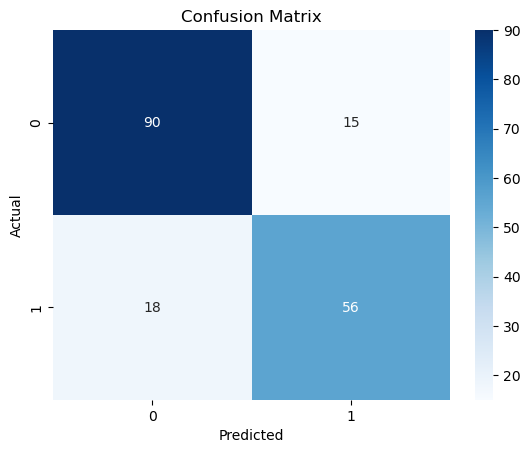

In [4]:
# LOAD DATASET
titanic_df = sns.load_dataset('titanic')

# FIRST 5 ROWS
print(titanic_df.head())

# INFORMATION ABOUT DATASET
titanic_df.info()

# CHECK MISSING VALUES
print(titanic_df.isnull().sum())

# VISUALIZE SURVIVAL COUNT
sns.countplot(x='survived', data=titanic_df)
plt.title('Survival Count (0 = No, 1 = Yes)')
plt.show()


# VISUALIZE SURVIVAL BASED ON GENDERS
sns.countplot(x = 'survived', hue = 'sex',data = titanic_df)
plt.title('Survival by Gender')
plt.show()

# DROPING COLUMNS
titanic_df = titanic_df.drop(['deck','embark_town','alive', 'who','adult_male','class'],axis = 1)

# FILL MISSING 'AGE'VALUES
titanic_df['age'].fillna(titanic_df['age'].median(),inplace = True)

# FILL MISSING 'EMBARKED' VALUES
titanic_df['embarked'].fillna(titanic_df['embarked'].mode()[0], inplace=True)


# ENCODING
titanic_df = pd.get_dummies(titanic_df, columns = ['sex','embarked'],drop_first = True)

X = titanic_df.drop('survived',axis = 1)
y = titanic_df['survived']

# SPLIT DATA
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

# TRAIN MODEL
model = RandomForestClassifier(n_estimators=100,random_state = 42)
model.fit(X_train, y_train)

# PREDICTION ON TEST DATA
y_pred = model.predict(X_test)

# ACCURACY SCORE
accuracy = accuracy_score(y_test, y_pred)

# CLASSIFICATION REPORT
print(classification_report(y_test,y_pred))

# CONFUSION MATRIX
CM = confusion_matrix(y_test, y_pred)
sns.heatmap(CM, annot = True, fmt = 'd', cmap = 'Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()